# 고혈압 예측 - CatBoost Feature Engineering 실험

- 타겟: `고혈압유병` (0: 없음 / 1: 있음)
- 데이터: hn_all_preprocessed.csv
- 모델: CatBoost (Optuna 최적 파라미터 고정)
- Threshold: 0.50 고정
- 목적: **피처 추가·제거 실험으로 성능 변화 확인**
- 검증: Stratified 5-Fold CV

In [23]:
import os
import sys
import warnings

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings("ignore")
matplotlib.rcParams["font.family"] = "DejaVu Sans"

# ── 경로 설정 (상대 경로) ──────────────────────────────────
CURRENT_DIR = os.path.dirname(os.path.abspath(""))
BASE_DIR = os.path.join(CURRENT_DIR, "..")
DATA_PATH = os.path.join(BASE_DIR, "data", "hn_all_preprocessed.csv")
FEATURES_DIR = os.path.join(BASE_DIR, "features")
NPY_DIR = os.path.join(BASE_DIR, "outputs", "oof")
sys.path.insert(0, FEATURES_DIR)

RANDOM_STATE = 42
THRESHOLD = 0.50

## 1. 데이터 로드

In [13]:
df = pd.read_csv(DATA_PATH)
print(f"로드 완료 | shape: {df.shape}")

로드 완료 | shape: (6033, 32)


## 2. ✏️ Feature Engineering 설정

> **실험 방법:** 추가하고 싶은 피처 함수의 주석을 해제하세요.
> 순서 중요: `add_age_bin` → `add_family_sum` → 나머지

In [14]:
# ── 피처 엔지니어링 함수 import ──────────────────────────────
from fe_age_bin import add_age_bin  # 나이_구간

# ── 적용할 피처 선택 (주석 해제 = 적용) ──────────────────────
df = add_age_bin(df)  # 나이_구간
# df = add_family_sum(df,                 # 가족력_합계
#                     hypertension=True,
#                     diabetes=True,
#                     dyslipidemia=True)
# df = add_bmi_bin(df)                  # BMI_구간 (필요 시 해제)
# df = add_alcohol_load(df)             # 음주_총부하 (필요 시 해제)
# df = add_exercise_total(df)           # 총운동일수 (필요 시 해제)
# df = add_body_features(df)            # 체형 복합 (필요 시 해제)
# df = add_age_family_interaction(df,   # 나이×가족력 (필요 시 해제)
#                                 hypertension=True, diabetes=False)

print(f"\n피처 엔지니어링 완료 | shape: {df.shape}")

[fe_age_bin] '나이_구간' 추가 완료
  분포:
나이_구간
0    1353
1     935
2    1128
3    2617
  (0: 19~39세 / 1: 40~49세 / 2: 50~59세 / 3: 60세 이상)

피처 엔지니어링 완료 | shape: (6033, 33)


## 3. 피처 / 타겟 분리

In [15]:
TARGET = "고혈압유병"
DROP_COLS = ["고혈압유병", "당뇨유병", "이상지질혈증유병", "비만단계"]

data = df.dropna(subset=[TARGET]).copy()
X = data.drop(columns=DROP_COLS)
y = data[TARGET].astype(int)
neg, pos = (y == 0).sum(), (y == 1).sum()
ratio = neg / pos

print(f"샘플 수: {len(y)}  |  정상: {neg}  |  고혈압: {pos}")
print(f"사용 피처 수: {X.shape[1]}")
print(f"피처 목록: {list(X.columns)}")

샘플 수: 6033  |  정상: 4353  |  고혈압: 1680
사용 피처 수: 29
피처 목록: ['성별', '나이', '키', '체중', 'BMI', '현재흡연', '고혈압가족력_부', '고혈압가족력_모', '고혈압가족력_형제', '당뇨가족력_부', '당뇨가족력_모', '당뇨가족력_형제', '고지혈증가족력_부', '고지혈증가족력_모', '고지혈증가족력_형제', '걷기일수', '근력운동일수', '과거음주_현재금주', '음주빈도_enc', '음주량_enc', '직업_관리전문', '직업_기능노무', '직업_농림어업', '직업_무직', '직업_사무', '직업_서비스판매', '직업_작업미상', '직업_주부학생', '나이_구간']


## 4. Optuna 최적 파라미터 설정

In [16]:
best_params = dict(
    iterations=471,
    learning_rate=0.032764733319141724,
    depth=8,
    l2_leaf_reg=4.203321840281557,
    bagging_temperature=0.5901763665642024,
    random_strength=0.0037317573233671512,
    border_count=79,
    loss_function="Logloss",
    eval_metric="AUC",
    class_weights={0: 1.0, 1: ratio},
    early_stopping_rounds=50,
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False,
)
print("파라미터 설정 완료")

파라미터 설정 완료


## 5. Stratified 5-Fold CV

In [17]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_proba = np.zeros(len(y))
fold_scores = []

print("=" * 65)
for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
    model = CatBoostClassifier(**best_params)
    model.fit(Pool(X_tr, y_tr), eval_set=Pool(X_val, y_val))
    proba = model.predict_proba(X_val)[:, 1]
    oof_proba[val_idx] = proba
    pred = (proba >= THRESHOLD).astype(int)
    cm_f = confusion_matrix(y_val, pred)
    fold_scores.append(
        {
            "fold": fold,
            "auc": roc_auc_score(y_val, proba),
            "f1": f1_score(y_val, pred),
            "recall": recall_score(y_val, pred),
            "precision": precision_score(y_val, pred),
            "fp": int(cm_f[0, 1]),
            "best_iter": model.best_iteration_,
        }
    )
    print(
        f"  Fold {fold} | AUC: {fold_scores[-1]['auc']:.4f} | "
        f"Recall: {fold_scores[-1]['recall']:.4f} | "
        f"F1: {fold_scores[-1]['f1']:.4f} | "
        f"best_iter: {model.best_iteration_}"
    )

scores_df = pd.DataFrame(fold_scores)
print("=" * 65)
print(
    f"  평균   | AUC: {scores_df.auc.mean():.4f}±{scores_df.auc.std():.4f} "
    f"| Recall: {scores_df.recall.mean():.4f}±{scores_df.recall.std():.4f} "
    f"| F1: {scores_df.f1.mean():.4f}±{scores_df.f1.std():.4f}"
)

  Fold 1 | AUC: 0.8494 | Recall: 0.8512 | F1: 0.6449 | best_iter: 52
  Fold 2 | AUC: 0.8492 | Recall: 0.8036 | F1: 0.6236 | best_iter: 30
  Fold 3 | AUC: 0.8752 | Recall: 0.8512 | F1: 0.6810 | best_iter: 78
  Fold 4 | AUC: 0.8265 | Recall: 0.7917 | F1: 0.6136 | best_iter: 46
  Fold 5 | AUC: 0.8782 | Recall: 0.8244 | F1: 0.6707 | best_iter: 91
  평균   | AUC: 0.8557±0.0213 | Recall: 0.8244±0.0271 | F1: 0.6467±0.0291


## 6. OOF proba 저장 (.npy)

In [18]:
os.makedirs(NPY_DIR, exist_ok=True)
npy_path = os.path.join(NPY_DIR, "oof_proba_HTN_catboost_fe.npy")
oof_array = np.stack([oof_proba, y.values], axis=1)
np.save(npy_path, oof_array)
print(f"저장 완료 → {npy_path}")
loaded = np.load(npy_path)
print(f"로드 확인: shape={loaded.shape}, 일치={np.allclose(oof_array, loaded)}")

저장 완료 → /Users/Jiyeon/Desktop/final_project/ML/model/../outputs/oof/oof_proba_HTN_catboost_fe.npy
로드 확인: shape=(6033, 2), 일치=True


## 7. OOF 성능 & 기준 모델 비교

In [19]:
pred_oof = (oof_proba >= THRESHOLD).astype(int)
cm = confusion_matrix(y, pred_oof)

oof_auc = roc_auc_score(y, oof_proba)
oof_rec = recall_score(y, pred_oof)
oof_prec = precision_score(y, pred_oof)
oof_f1 = f1_score(y, pred_oof)
oof_acc = float((pred_oof == y).mean())

# 기준 모델 (FE 없음, Optuna)
BASE = {"auc": 0.8553, "recall": 0.8357, "precision": 0.5344, "f1": 0.6520, "acc": 0.7515, "fp": 1223, "fn": 276}

print("=" * 55)
print(f"  {'지표':<12}  {'기준 모델':>12}  {'FE 적용':>10}  변화")
print("=" * 55)
for label, base_v, cur_v in [
    ("AUC-ROC", BASE["auc"], oof_auc),
    ("Recall", BASE["recall"], oof_rec),
    ("Precision", BASE["precision"], oof_prec),
    ("F1-score", BASE["f1"], oof_f1),
    ("Accuracy", BASE["acc"], oof_acc),
]:
    d = cur_v - base_v
    arrow = "▲" if d > 0 else ("▼" if d < 0 else "─")
    print(f"  {label:<12}  {base_v:>12.4f}  {cur_v:>10.4f}  {arrow} {abs(d):.4f}")
print(
    f"  {'FP':<12}  {BASE['fp']:>12}  {cm[0, 1]:>10}  {'▼' if cm[0, 1] < BASE['fp'] else '▲'} {abs(cm[0, 1] - BASE['fp'])}"
)
print(
    f"  {'FN':<12}  {BASE['fn']:>12}  {cm[1, 0]:>10}  {'▼' if cm[1, 0] < BASE['fn'] else '▲'} {abs(cm[1, 0] - BASE['fn'])}"
)
print("=" * 55)
print("\n[분류 리포트]")
print(classification_report(y, pred_oof, target_names=["정상(0)", "고혈압(1)"]))

  지표                   기준 모델       FE 적용  변화
  AUC-ROC             0.8553      0.8557  ▲ 0.0004
  Recall              0.8357      0.8244  ▼ 0.0113
  Precision           0.5344      0.5315  ▼ 0.0029
  F1-score            0.6520      0.6463  ▼ 0.0057
  Accuracy            0.7515      0.7487  ▼ 0.0028
  FP                    1223        1221  ▼ 2
  FN                     276         295  ▲ 19

[분류 리포트]
              precision    recall  f1-score   support

       정상(0)       0.91      0.72      0.81      4353
      고혈압(1)       0.53      0.82      0.65      1680

    accuracy                           0.75      6033
   macro avg       0.72      0.77      0.73      6033
weighted avg       0.81      0.75      0.76      6033



## 8. Confusion Matrix

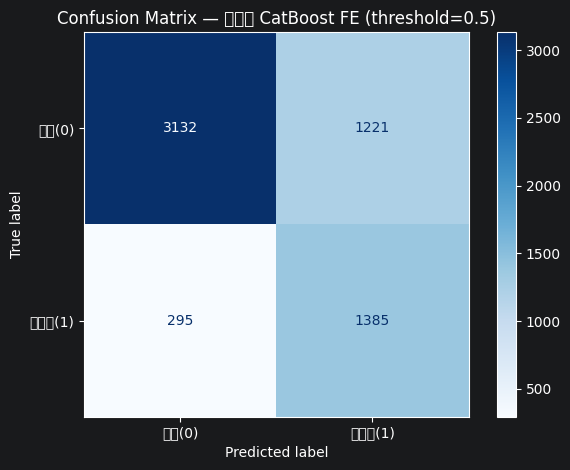

In [20]:
disp = ConfusionMatrixDisplay(cm, display_labels=["정상(0)", "고혈압(1)"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix — 고혈압 CatBoost FE (threshold={THRESHOLD})")
plt.tight_layout()
plt.show()

## 9. Feature Importance (CatBoost, 마지막 fold)

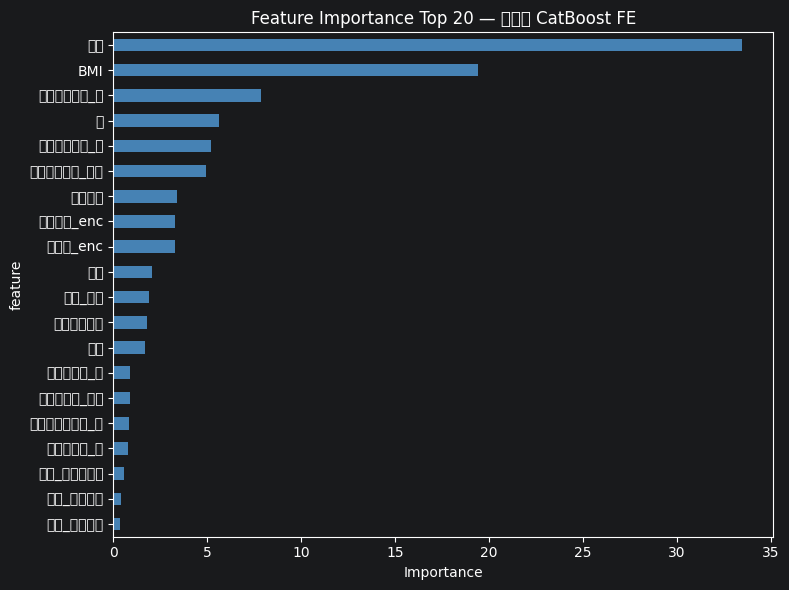

  feature  importance
       나이   33.429247
      BMI   19.386444
 고혈압가족력_모    7.835615
        키    5.617262
 고혈압가족력_부    5.181842
고혈압가족력_형제    4.958230
     걷기일수    3.375766
 음주빈도_enc    3.308920
  음주량_enc    3.295603
       체중    2.064626
    직업_무직    1.905633
   근력운동일수    1.778857
       성별    1.696994
  당뇨가족력_부    0.893894
 당뇨가족력_형제    0.880606
고지혈증가족력_모    0.860940
  당뇨가족력_모    0.775800
 직업_서비스판매    0.551624
  직업_기능노무    0.392970
  직업_작업미상    0.349451


In [21]:
fi = pd.DataFrame({"feature": X.columns, "importance": model.get_feature_importance()}).sort_values(
    "importance", ascending=False
)

plt.figure(figsize=(8, 6))
fi.head(20).set_index("feature")["importance"][::-1].plot(kind="barh", color="steelblue")
plt.title("Feature Importance Top 20 — 고혈압 CatBoost FE")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()
print(fi.head(20).to_string(index=False))

## 10. DB 로그 저장

In [22]:
sys.path.insert(0, os.path.join(BASE_DIR))
from model_logger import ModelLogger

logger = ModelLogger(os.path.join(BASE_DIR, "model_result.db"))

# 적용된 FE 피처 목록
base_cols = pd.read_csv(DATA_PATH).columns.tolist()
fe_cols = [c for c in X.columns if c not in base_cols]
fe_note = f"FE 적용: {fe_cols}" if fe_cols else "FE 없음"

run_id = logger.log_run(
    target_var="고혈압",
    model_name="CatBoost",
    stage="fe_exp",
    hyperparams={
        "learning_rate": best_params["learning_rate"],
        "depth": best_params["depth"],
        "n_estimators": best_params["iterations"],
        "class_weight": {0: 1.0, 1: round(ratio, 4)},
        "l2_leaf_reg": best_params["l2_leaf_reg"],
        "bagging_temperature": best_params["bagging_temperature"],
        "random_strength": best_params["random_strength"],
        "border_count": best_params["border_count"],
    },
    data_info={
        "feature_count": X.shape[1],
        "train_test_split": "5-Fold CV",
        "scaling_method": "None",
    },
    oof_metrics={
        "accuracy": oof_acc,
        "recall": oof_rec,
        "precision": oof_prec,
        "f1_score": oof_f1,
        "auc_roc": oof_auc,
        "cm": cm.tolist(),
    },
    fold_scores=scores_df.to_dict("records"),
    top_features=fi.set_index("feature")["importance"].head(15).to_dict(),
    note=fe_note,
)
print(f"저장 완료 → run_id: {run_id}  |  {fe_note}")
print(logger.compare_runs().to_string(index=False))

[ModelLogger] 저장 완료 | run_id=17 | 고혈압 CatBoost (fe_exp)
저장 완료 → run_id: 17  |  FE 적용: ['나이_구간']
 run_id          created_at target_var model_name          stage  auc_roc   recall  precision  f1_score  accuracy
     17 2026-05-17 16:39:19        고혈압   CatBoost         fe_exp 0.855698 0.824405   0.531466  0.646290  0.748715
     16 2026-05-16 00:35:27        고혈압   CatBoost    optuna_shap 0.855328 0.835714   0.534450  0.651962  0.751533
     15 2026-05-16 00:35:23         당뇨   CatBoost    optuna_shap 0.824642 0.802713   0.289205  0.425212  0.708271
     14 2026-05-16 00:35:12     이상지질혈증   CatBoost    optuna_shap 0.825566 0.804236   0.497025  0.614366  0.739267
     13 2026-05-15 23:45:25     이상지질혈증   CatBoost threshold_0.45 0.834261 0.869705   0.456690  0.598895  0.699155
     12 2026-05-15 23:45:24         당뇨   CatBoost threshold_0.45 0.821971 0.842170   0.279346  0.419533  0.686723
     11 2026-05-15 23:45:23        고혈압   CatBoost threshold_0.50 0.858479 0.829762   0.530441  0.647168  0